# Gaussian indirect results across trained networks

The saved n=10 runs are compared across five network settings for S=40 (2D) and S=80 (4D). All figures use the existing Gaussian plotting function. No inference, thresholds, diagnostics, or result CSVs are generated here.


## Imports


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(
    (
        parent
        for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (parent / "examples" / "gaussian").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from the repository root or a directory within it.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from examples.gaussian.analysis.plot import load_runs, plot_metric_grid


## Result directories


In [2]:
GAUSSIAN_RESULT_DIR = ROOT / "examples" / "gaussian" / "results"
RESULT_DIRS = {
    "default": GAUSSIAN_RESULT_DIR,
    "seed_2026": GAUSSIAN_RESULT_DIR / "ablation" / "seed_2026",
    "fixed_lr": GAUSSIAN_RESULT_DIR / "ablation" / "fixed_lr",
    "no_standardize": GAUSSIAN_RESULT_DIR / "ablation" / "no_standardize",
    "summary_only": GAUSSIAN_RESULT_DIR / "ablation" / "summary_only",
}
SETTING_LABELS = {
    "default": "Default",
    "seed_2026": "Different seed",
    "fixed_lr": "Fixed learning rate",
    "no_standardize": "No standardization",
    "summary_only": "Summary-only standardization",
}
SUMMARY_DIMS = (40, 80)
RUN_LABELS = {40: "S=2D", 80: "S=4D"}
KEYS = ["source_model", "id", "candidate_model"]


## Load saved indirect runs


In [3]:
all_runs = {
    setting: load_runs(
        method="indirect",
        num_obs=10,
        summary_dims=list(SUMMARY_DIMS),
        result_dir=result_dir,
    )
    for setting, result_dir in RESULT_DIRS.items()
}
for setting, runs in all_runs.items():
    if set(runs) != set(RUN_LABELS.values()):
        raise ValueError(f"{setting}: expected only S=2D and S=4D, got {list(runs)}")
    print(f"{SETTING_LABELS[setting]}: {', '.join(runs)}")


Default: S=2D, S=4D
Different seed: S=2D, S=4D
Fixed learning rate: S=2D, S=4D
No standardization: S=2D, S=4D
Summary-only standardization: S=2D, S=4D


## Check paired datasets and shared gold standards


In [4]:
for dim, run_label in RUN_LABELS.items():
    baseline = all_runs["default"][run_label].set_index(KEYS).sort_index()
    for setting in RESULT_DIRS:
        aligned = all_runs[setting][run_label].set_index(KEYS).sort_index()
        if not aligned.index.equals(baseline.index):
            raise ValueError(f"{setting}, S={dim}: source_model/id/candidate_model rows differ from default")
        for column in ("gold_logml", "gold_pmp"):
            if column not in baseline or column not in aligned:
                raise ValueError(f"{setting}, S={dim}: missing {column}")
            if not np.isfinite(baseline[column].to_numpy(float)).all():
                raise ValueError(f"default, S={dim}: {column} contains non-finite values")
            try:
                pd.testing.assert_series_equal(baseline[column], aligned[column], check_exact=True)
            except AssertionError as exc:
                raise ValueError(f"{setting}, S={dim}: {column} differs from default") from exc

print("All five settings have identical dataset keys and gold_logml/gold_pmp values at S=40 and S=80.")


All five settings have identical dataset keys and gold_logml/gold_pmp values at S=40 and S=80.


## Posterior MMD figures


### Default


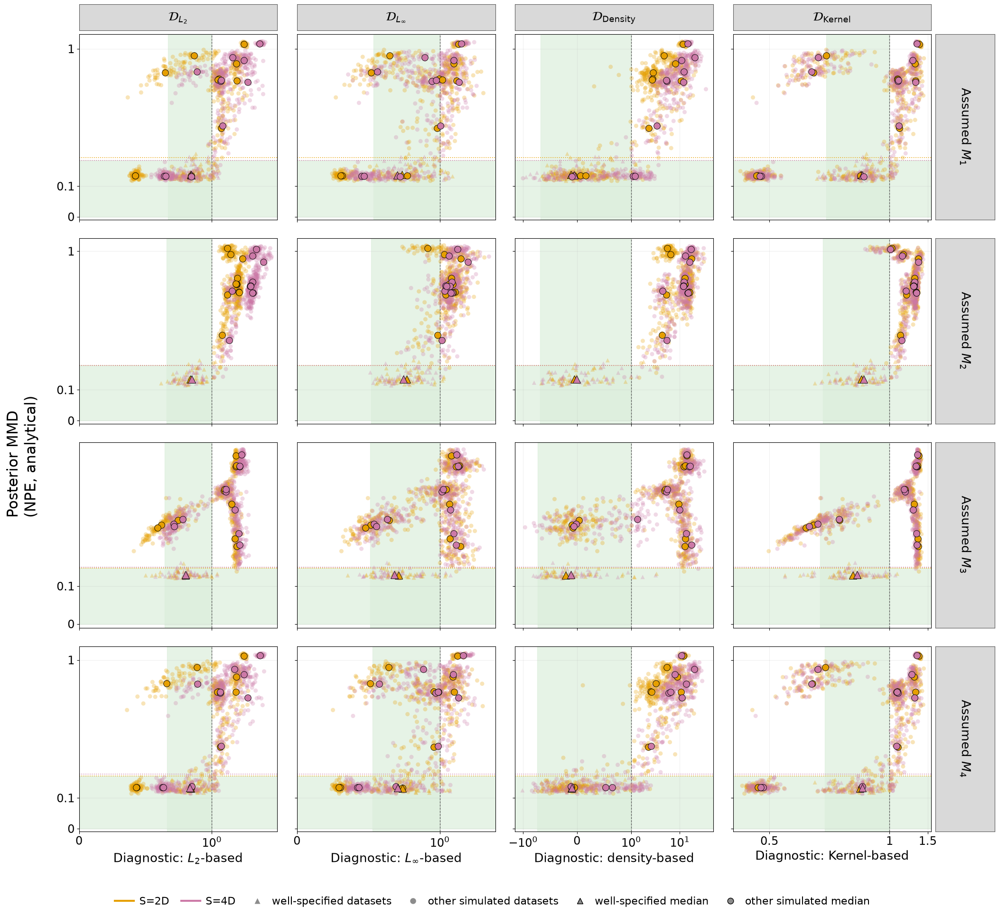

In [5]:
fig, _ = plot_metric_grid(all_runs["default"], metric="posterior_mmd")
display(fig)
plt.close(fig)


### Different seed


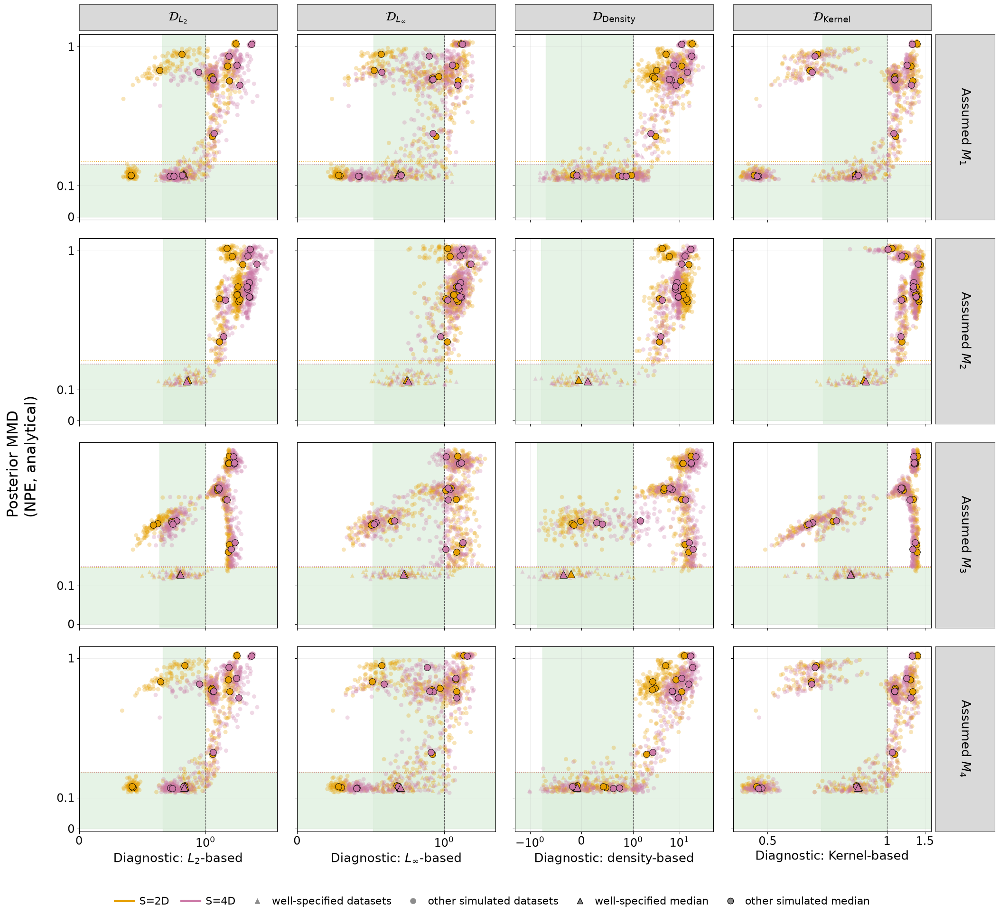

In [6]:
fig, _ = plot_metric_grid(all_runs["seed_2026"], metric="posterior_mmd")
display(fig)
plt.close(fig)


### Fixed learning rate


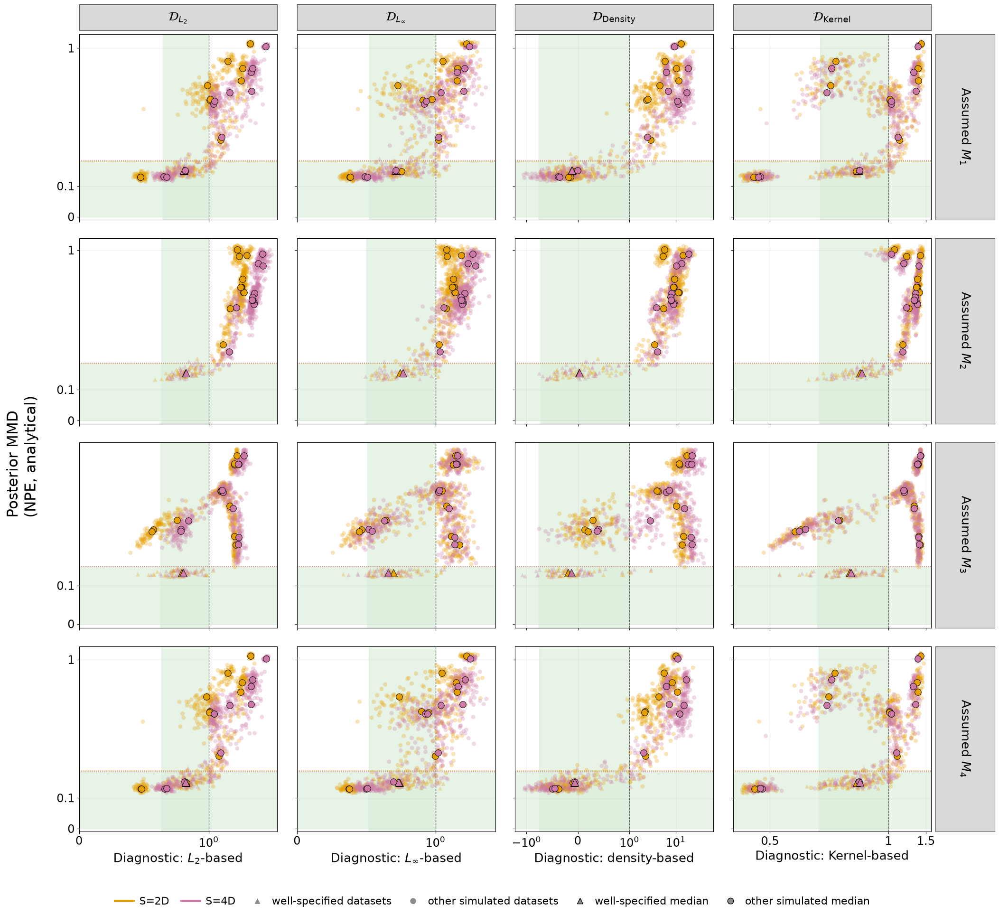

In [7]:
fig, _ = plot_metric_grid(all_runs["fixed_lr"], metric="posterior_mmd")
display(fig)
plt.close(fig)


### No standardization


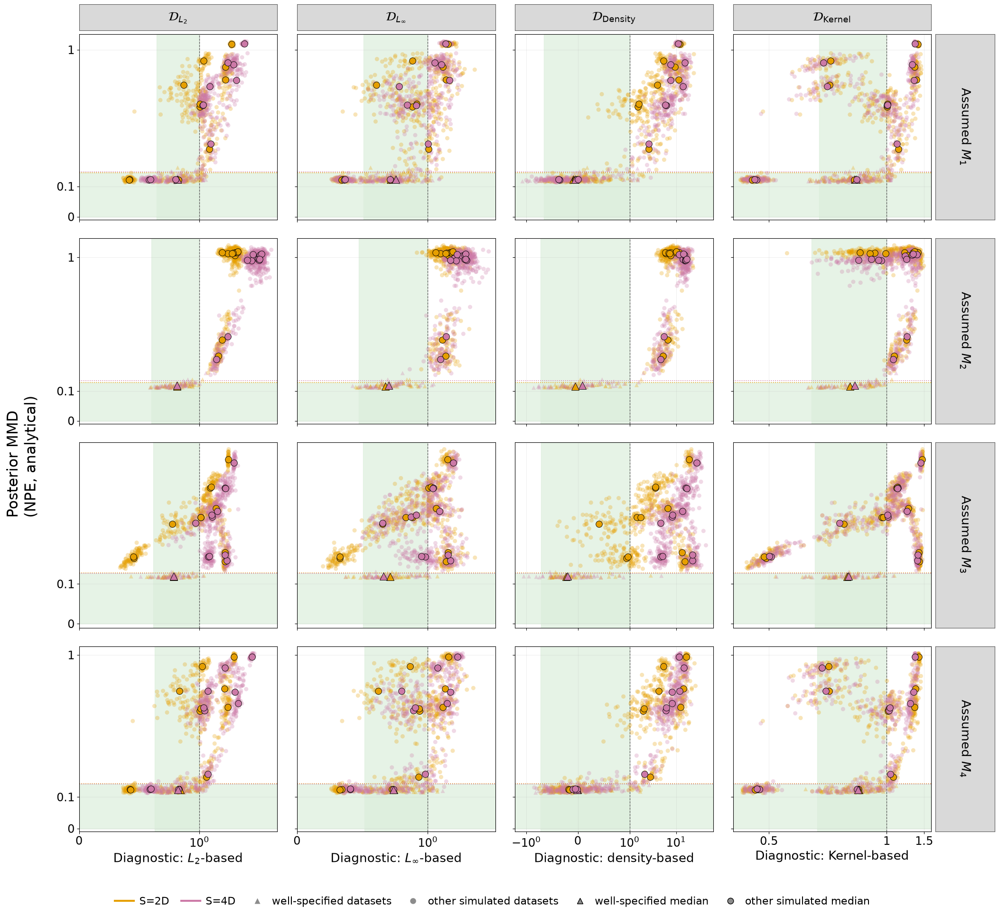

In [8]:
fig, _ = plot_metric_grid(all_runs["no_standardize"], metric="posterior_mmd")
display(fig)
plt.close(fig)


### Summary-only standardization


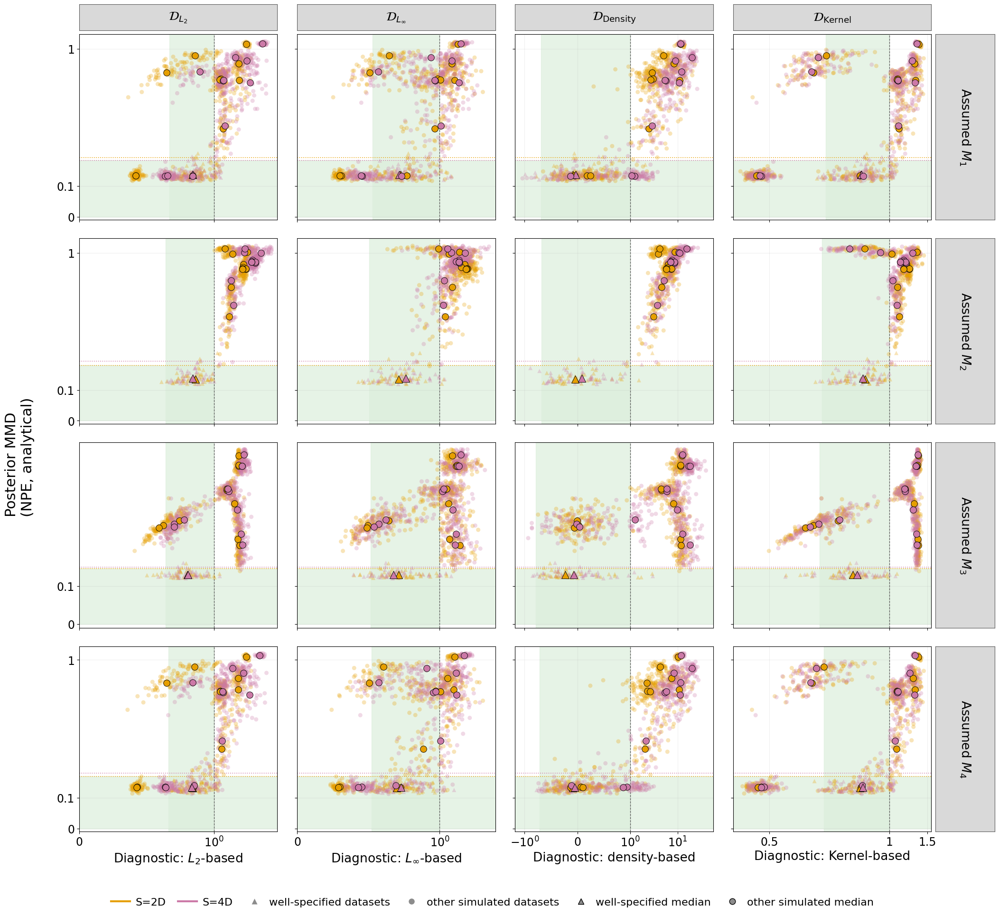

In [9]:
fig, _ = plot_metric_grid(all_runs["summary_only"], metric="posterior_mmd")
display(fig)
plt.close(fig)


## Log10 marginal-likelihood error figures


### Default


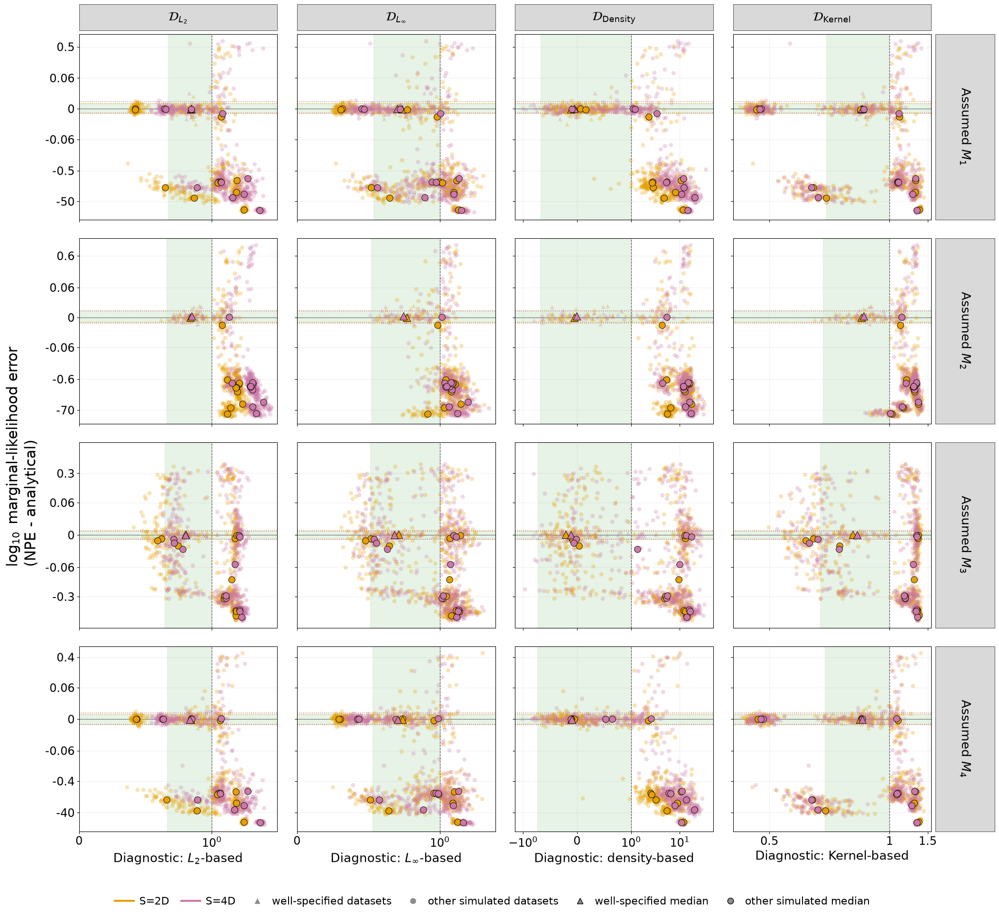

In [10]:
fig, _ = plot_metric_grid(all_runs["default"], metric="logml")
display(fig)
plt.close(fig)


### Different seed


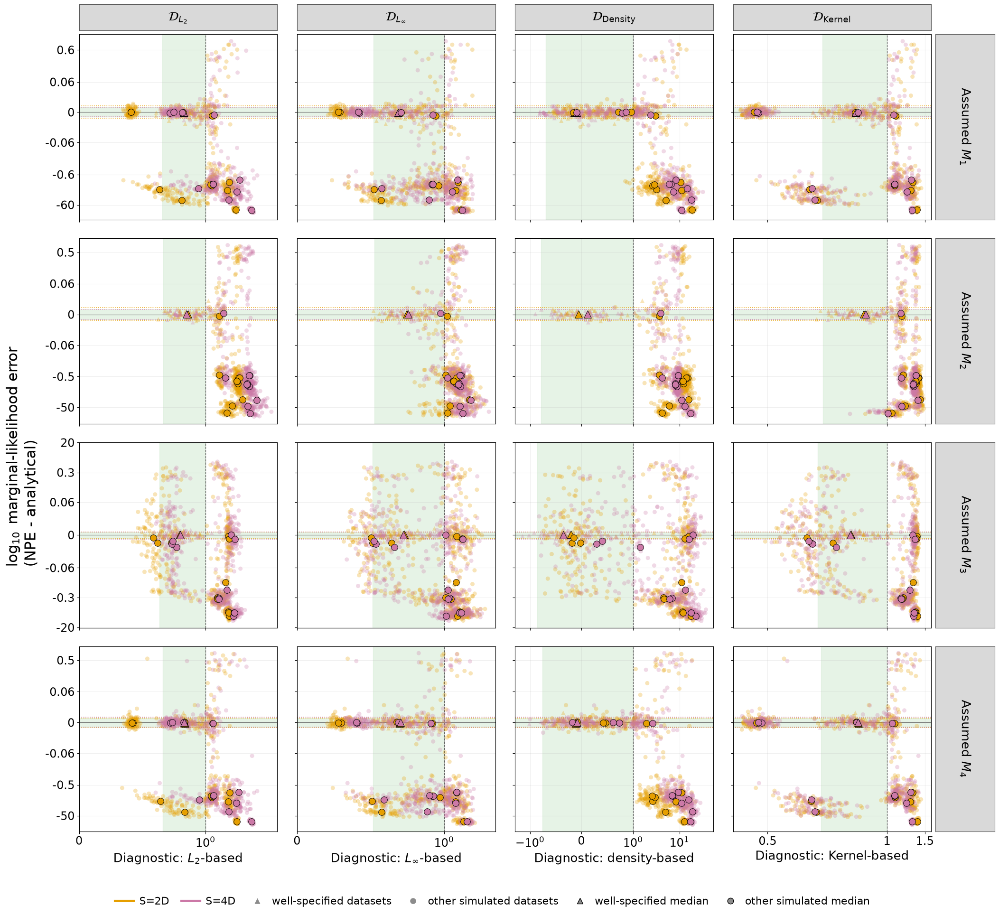

In [11]:
fig, _ = plot_metric_grid(all_runs["seed_2026"], metric="logml")
display(fig)
plt.close(fig)


### Fixed learning rate


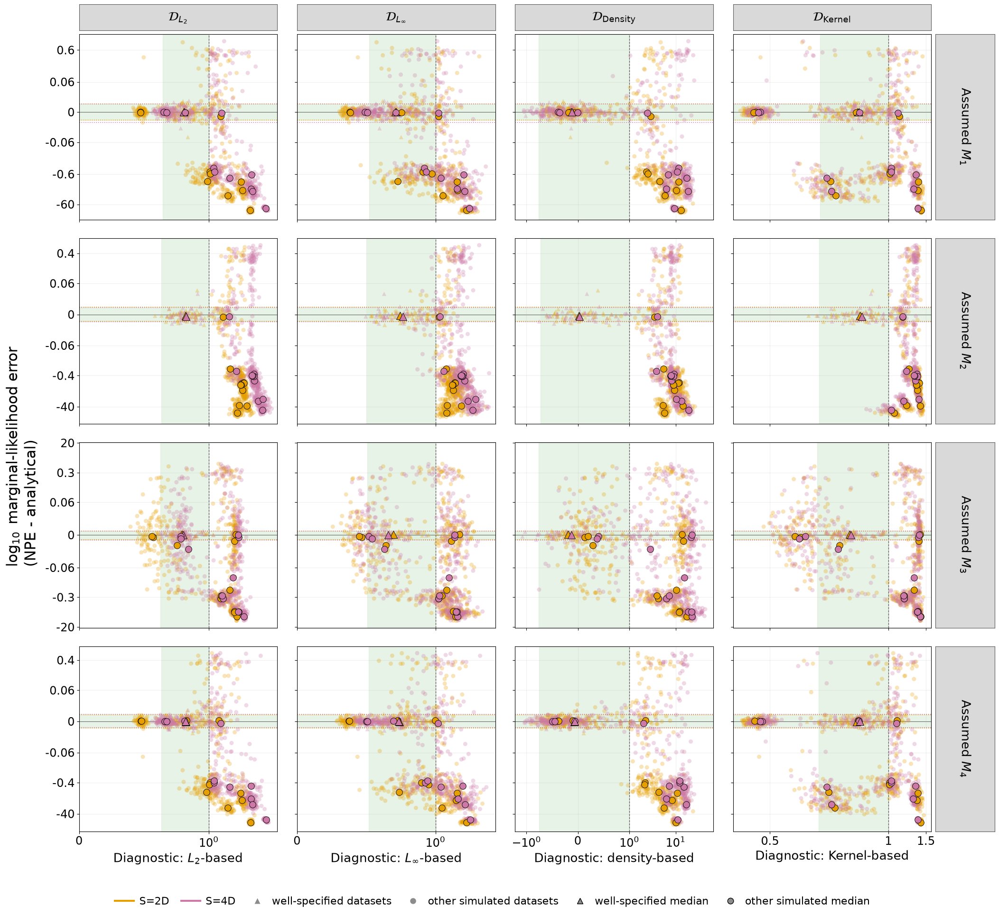

In [12]:
fig, _ = plot_metric_grid(all_runs["fixed_lr"], metric="logml")
display(fig)
plt.close(fig)


### No standardization


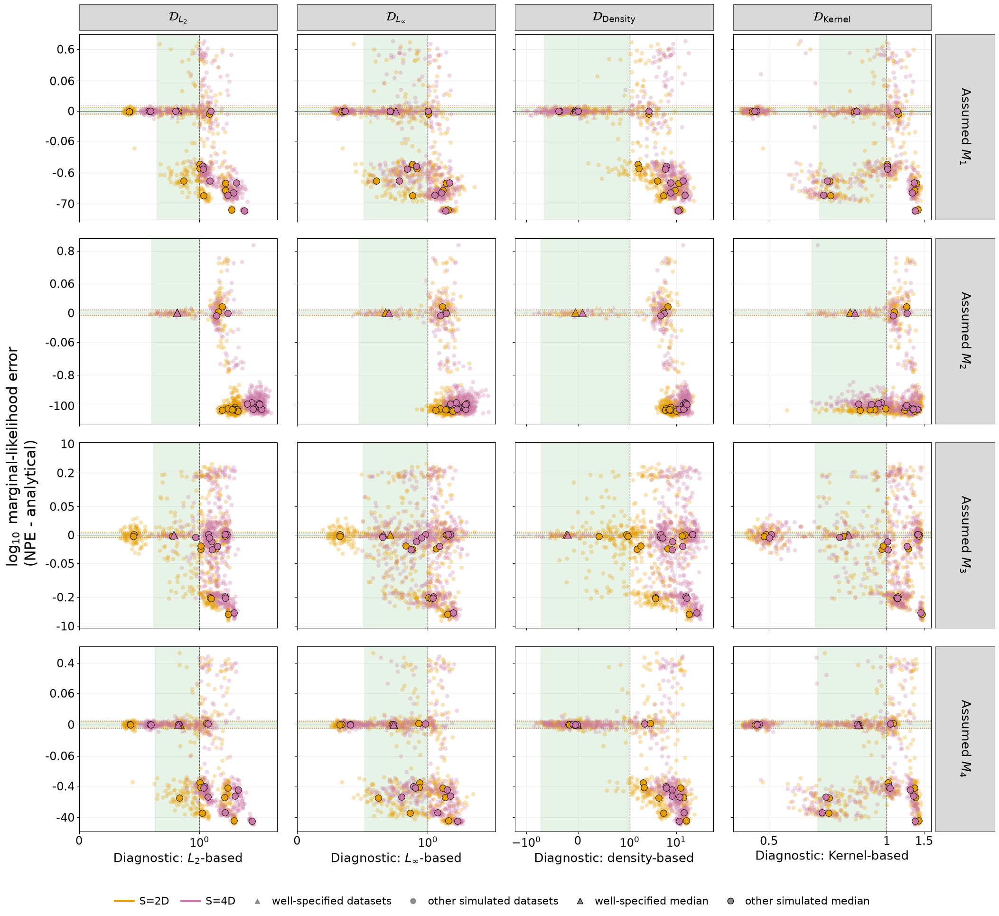

In [13]:
fig, _ = plot_metric_grid(all_runs["no_standardize"], metric="logml")
display(fig)
plt.close(fig)


### Summary-only standardization


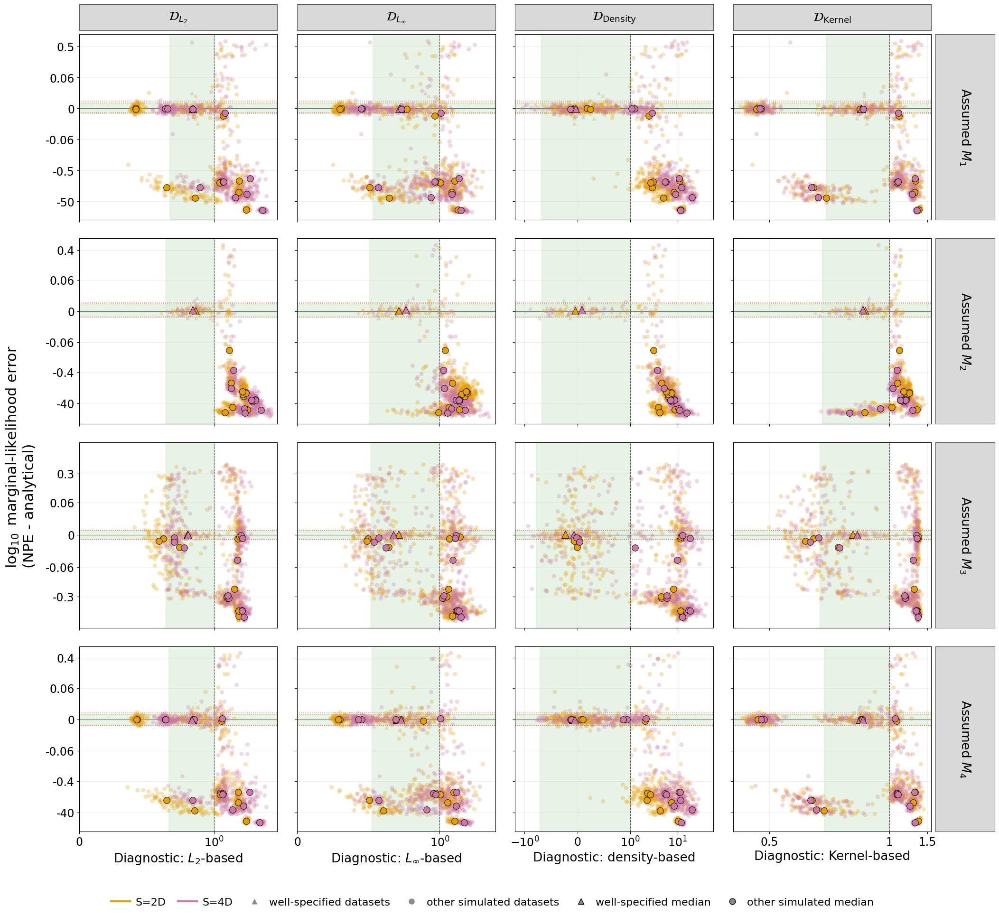

In [14]:
fig, _ = plot_metric_grid(all_runs["summary_only"], metric="logml")
display(fig)
plt.close(fig)


## PMP error figures


The common PMP y-axis range is −1.05 to 1.05. Marker and high-surprise definitions come from the existing plotting code.


### Default


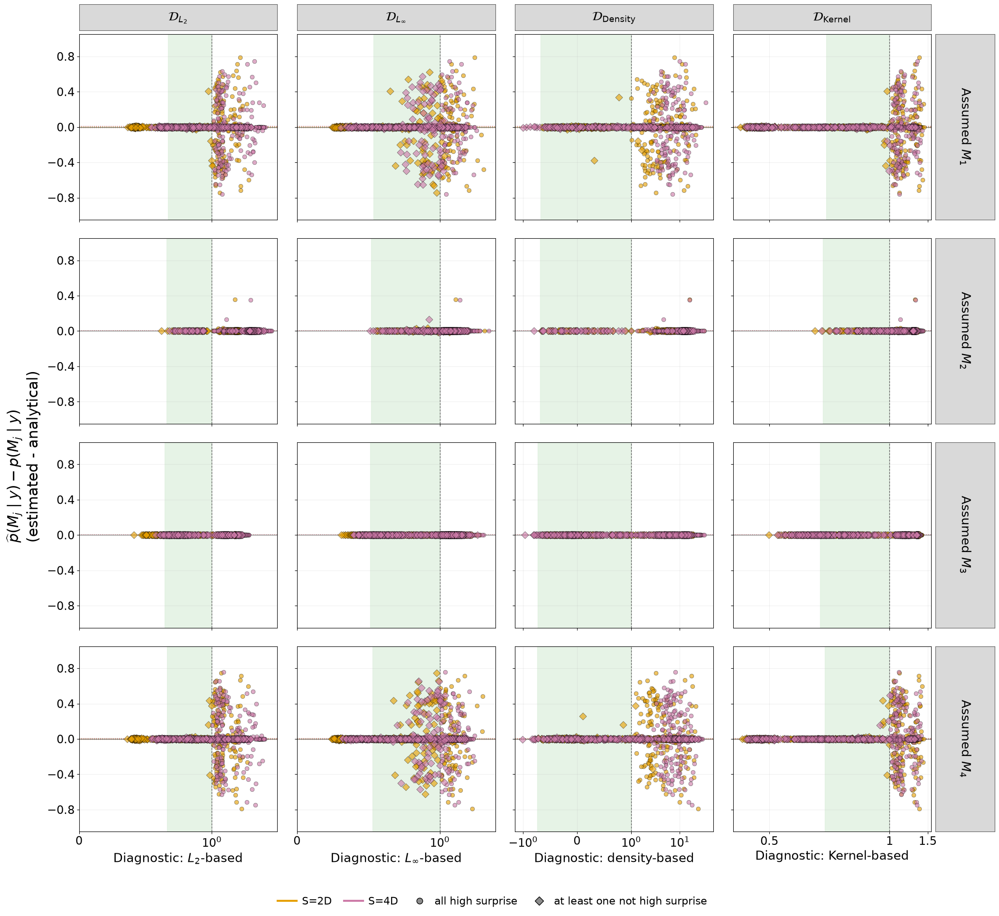

In [15]:
fig, _ = plot_metric_grid(all_runs["default"], metric="pmp", ylim=(-1.05, 1.05))
display(fig)
plt.close(fig)


### Different seed


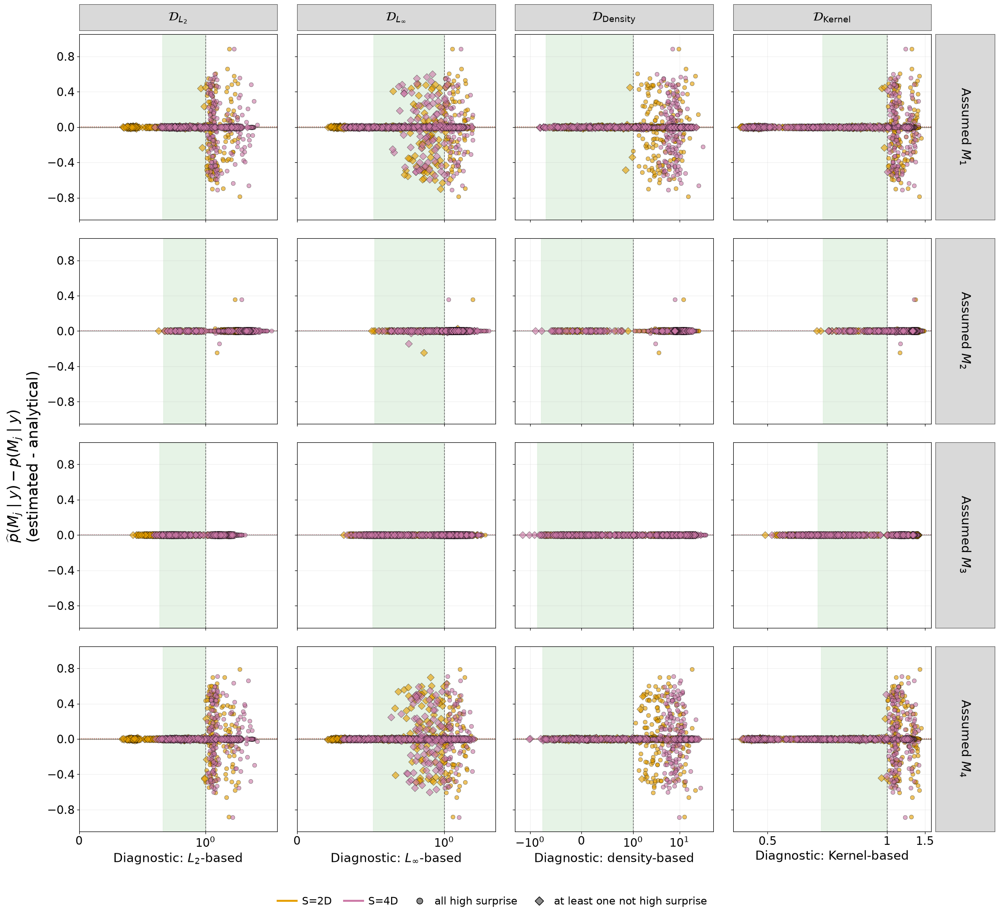

In [16]:
fig, _ = plot_metric_grid(all_runs["seed_2026"], metric="pmp", ylim=(-1.05, 1.05))
display(fig)
plt.close(fig)


### Fixed learning rate


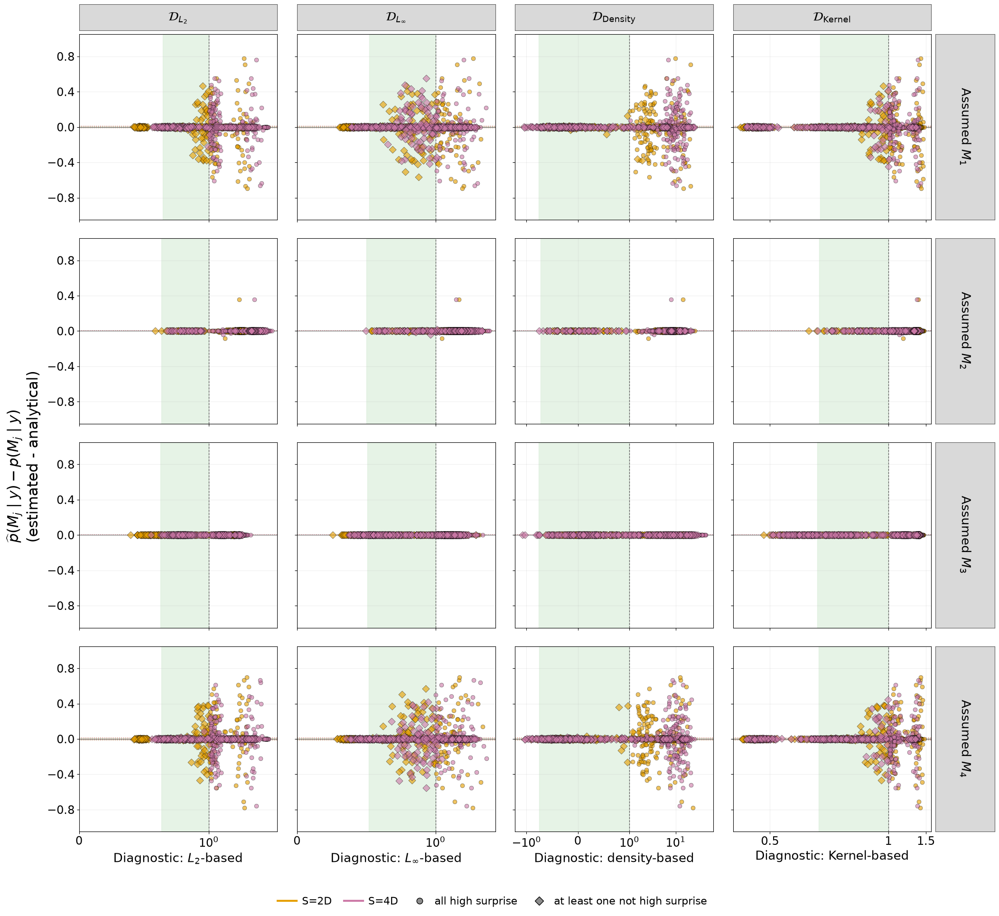

In [17]:
fig, _ = plot_metric_grid(all_runs["fixed_lr"], metric="pmp", ylim=(-1.05, 1.05))
display(fig)
plt.close(fig)


### No standardization


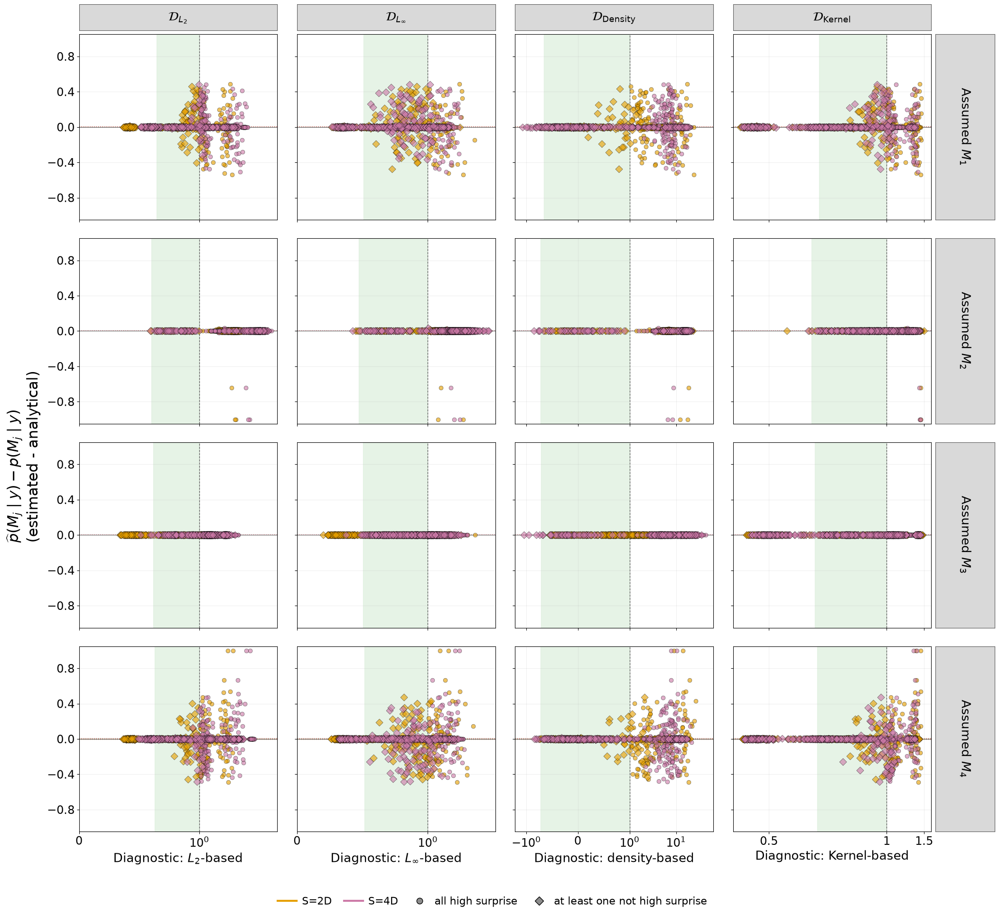

In [18]:
fig, _ = plot_metric_grid(all_runs["no_standardize"], metric="pmp", ylim=(-1.05, 1.05))
display(fig)
plt.close(fig)


### Summary-only standardization


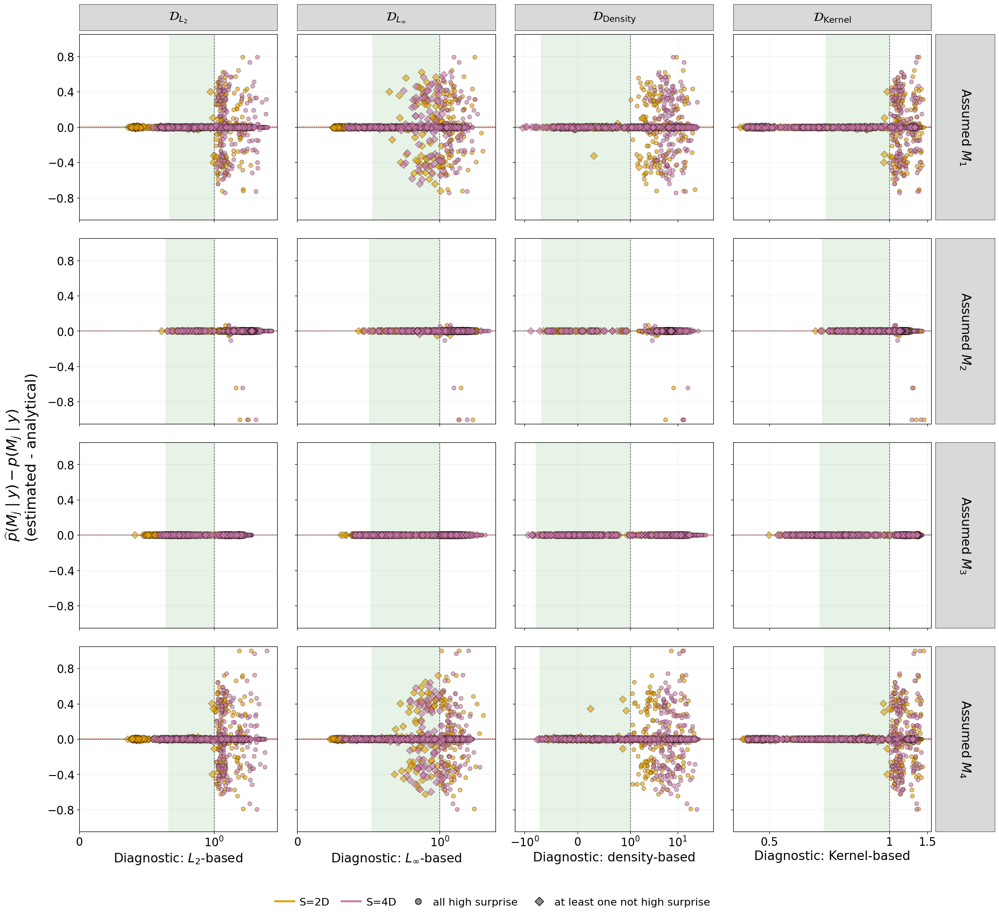

In [19]:
fig, _ = plot_metric_grid(all_runs["summary_only"], metric="pmp", ylim=(-1.05, 1.05))
display(fig)
plt.close(fig)


## Inference accuracy summary

Medians use the saved result columns. Posterior MMD, absolute logML error, and absolute PMP error summarize candidate-model rows. PMP L1 error is counted once per observed dataset (source_model, id).


In [20]:
summary_rows = []
for setting, runs in all_runs.items():
    for dim, run_label in RUN_LABELS.items():
        frame = runs[run_label]
        dataset_keys = ["source_model", "id"]
        if not frame.groupby(dataset_keys)["pmp_l1_error"].nunique(dropna=False).eq(1).all():
            raise ValueError(f"{setting}, S={dim}: pmp_l1_error differs across candidate rows")
        dataset_pmp_l1 = frame.drop_duplicates(dataset_keys)["pmp_l1_error"]
        summary_rows.append({
            "setting": SETTING_LABELS[setting],
            "summary_dim": dim,
            "median posterior_mmd": frame["posterior_mmd"].median(),
            "median absolute_logml_error": frame["absolute_logml_error"].median(),
            "median absolute_pmp_error": frame["absolute_pmp_error"].median(),
            "median dataset pmp_l1_error": dataset_pmp_l1.median(),
        })

inference_summary = pd.DataFrame(summary_rows).set_index(["setting", "summary_dim"])
display(inference_summary.round(4))


median posterior_mmd  \
setting                      summary_dim                         
Default                      40                         0.4853   
                             80                         0.4864   
Different seed               40                         0.4480   
                             80                         0.4719   
Fixed learning rate          40                         0.4001   
                             80                         0.3720   
No standardization           40                         0.3429   
                             80                         0.3494   
Summary-only standardization 40                         0.5216   
                             80                         0.5309   

                                          median absolute_logml_error  \
setting                      summary_dim                                
Default                      40                                1.8041   
                             80                                1.9559   
Different seed               40                                1.3328   
                             80                                1.4608   
Fixed learning rate          40                                0.8456   
                             80                                0.5592   
No standardization           40                                0.3724   
                             80                                0.4400   
Summary-only standardization 40                                3.3163   
                             80                                3.9162   

                                          median absolute_pmp_error  \
setting                      summary_dim                              
Default                      40                                 0.0   
                             80                                 0.0   
Different seed               40                                 0.0   
                             80                                 0.0   
Fixed learning rate          40                                 0.0   
                             80                                 0.0   
No standardization           40                                 0.0   
                             80                                 0.0   
Summary-only standardization 40                                 0.0   
                             80                                 0.0   

                                          median dataset pmp_l1_error  
setting                      summary_dim                               
Default                      40                                0.0048  
                             80                                0.0046  
Different seed               40                                0.0049  
                             80                                0.0045  
Fixed learning rate          40                                0.0055  
                             80                                0.0053  
No standardization           40                                0.0029  
                             80                                0.0032  
Summary-only standardization 40                                0.0048  
                             80                                0.0047

## Paired differences from Default

Each variant row is matched to Default by source_model, id, and candidate_model. The table shows the median signed change and the 90th percentile of its absolute magnitude for each saved metric. Signed logML errors retain their saved units.


In [21]:
paired_metrics = ("posterior_mmd", "signed_logml_error", "signed_pmp_error")
paired_rows = []
for setting in ("seed_2026", "fixed_lr", "no_standardize", "summary_only"):
    for dim, run_label in RUN_LABELS.items():
        baseline = all_runs["default"][run_label].set_index(KEYS).sort_index()
        variant = all_runs[setting][run_label].set_index(KEYS).sort_index()
        delta = variant[list(paired_metrics)] - baseline[list(paired_metrics)]
        row = {"variant": SETTING_LABELS[setting], "summary_dim": dim}
        for metric in paired_metrics:
            row[f"median Δ {metric}"] = delta[metric].median()
            row[f"p90 |Δ {metric}|"] = delta[metric].abs().quantile(0.9)
        paired_rows.append(row)

paired_summary = pd.DataFrame(paired_rows).set_index(["variant", "summary_dim"])
display(paired_summary.round(4))


median Δ posterior_mmd  \
variant                      summary_dim                           
Different seed               40                          -0.0055   
                             80                          -0.0062   
Fixed learning rate          40                          -0.0162   
                             80                          -0.0399   
No standardization           40                          -0.0273   
                             80                          -0.0332   
Summary-only standardization 40                           0.0009   
                             80                           0.0012   

                                          p90 |Δ posterior_mmd|  \
variant                      summary_dim                          
Different seed               40                          0.1052   
                             80                          0.0778   
Fixed learning rate          40                          0.1351   
                             80                          0.1759   
No standardization           40                          0.4330   
                             80                          0.3746   
Summary-only standardization 40                          0.1697   
                             80                          0.2874   

                                          median Δ signed_logml_error  \
variant                      summary_dim                                
Different seed               40                                0.0176   
                             80                                0.0163   
Fixed learning rate          40                                0.1233   
                             80                                0.5742   
No standardization           40                                0.0100   
                             80                                0.0121   
Summary-only standardization 40                               -0.0026   
                             80                               -0.0077   

                                          p90 |Δ signed_logml_error|  \
variant                      summary_dim                               
Different seed               40                              21.6734   
                             80                              19.3461   
Fixed learning rate          40                              26.9470   
                             80                              46.4897   
No standardization           40                             331.0932   
                             80                             217.4540   
Summary-only standardization 40                              25.8112   
                             80                              62.1371   

                                          median Δ signed_pmp_error  \
variant                      summary_dim                              
Different seed               40                                 0.0   
                             80                                 0.0   
Fixed learning rate          40                                 0.0   
                             80                                 0.0   
No standardization           40                                 0.0   
                             80                                 0.0   
Summary-only standardization 40                                 0.0   
                             80                                 0.0   

                                          p90 |Δ signed_pmp_error|  
variant                      summary_dim                            
Different seed               40                             0.0737  
                             80                             0.0657  
Fixed learning rate          40                             0.0335  
                             80                             0.0402  
No standardization           40                             0.0420  
                             80             

## Detection performance from saved CSVs

FNR, FPR, and AUC come directly from detection.csv and global_pmp_detection.csv. Component rows below show the median of the four saved candidate-model values for each diagnostic. Global PMP rows use each saved value once. AUC rank 1 is the highest among l2, linf, density, and mmd.


In [22]:
DIAGNOSTICS = ("l2", "linf", "density", "mmd")
detection_frames = []
for setting, result_dir in RESULT_DIRS.items():
    for dim in SUMMARY_DIMS:
        comparison_dir = result_dir / "comparison" / "n10" / f"indirect_s{dim}"
        for filename, scope in (
            ("detection.csv", "component"),
            ("global_pmp_detection.csv", "global_pmp"),
        ):
            frame = pd.read_csv(comparison_dir / filename)
            if (
                not frame["method"].eq("indirect").all()
                or not frame["scope"].eq(scope).all()
                or set(frame["diagnostic"]) != set(DIAGNOSTICS)
            ):
                raise ValueError(f"{comparison_dir / filename}: unexpected saved detection rows")
            detection_frames.append(
                frame.assign(setting=SETTING_LABELS[setting], summary_dim=dim)
            )

detection_data = pd.concat(detection_frames, ignore_index=True)
detection_comparison = (
    detection_data
    .groupby(["scope", "error_metric", "setting", "summary_dim", "diagnostic"], sort=False)
    [["FNR", "FPR", "AUC"]]
    .median()
    .unstack("diagnostic")
)
detection_comparison = detection_comparison.reindex(
    columns=pd.MultiIndex.from_product([("FNR", "FPR", "AUC"), DIAGNOSTICS])
)
table_index = pd.MultiIndex.from_product(
    [SETTING_LABELS.values(), SUMMARY_DIMS], names=["setting", "summary_dim"]
)


### Posterior MMD detection


In [23]:
display(
    detection_comparison.loc[("component", "posterior_mmd")]
    .reindex(table_index)
    .round(3)
)


FNR                          FPR  \
                                             l2   linf density    mmd     l2   
setting                      summary_dim                                       
Default                      40           0.254  0.393   0.034  0.276  0.065   
                             80           0.108  0.383   0.016  0.269  0.065   
Different seed               40           0.271  0.440   0.035  0.279  0.079   
                             80           0.103  0.466   0.025  0.275  0.051   
Fixed learning rate          40           0.195  0.335   0.036  0.322  0.045   
                             80           0.019  0.257   0.020  0.298  0.068   
No standardization           40           0.276  0.480   0.082  0.376  0.023   
                             80           0.047  0.380   0.008  0.367  0.033   
Summary-only standardization 40           0.257  0.398   0.037  0.276  0.051   
                             80           0.112  0.378   0.022  0.269  0.062   

                                                                  AUC         \
                                           linf density    mmd     l2   linf   
setting                      summary_dim                                       
Default                      40           0.048   0.071  0.058  0.912  0.878   
                             80           0.039   0.149  0.077  0.972  0.907   
Different seed               40           0.061   0.110  0.083  0.904  0.868   
                             80           0.059   0.154  0.059  0.971  0.904   
Fixed learning rate          40           0.064   0.042  0.050  0.974  0.936   
                             80           0.038   0.055  0.070  0.992  0.970   
No standardization           40           0.023   0.023  0.023  0.949  0.907   
                             80           0.041   0.028  0.031  0.991  0.932   
Summary-only standardization 40           0.036   0.050  0.041  0.908  0.875   
                             80           0.062   0.148  0.070  0.969  0.907   

                                                         
                                         density    mmd  
setting                      summary_dim                 
Default                      40            0.988  0.879  
                             80            0.989  0.874  
Different seed               40            0.980  0.877  
                             80            0.985  0.877  
Fixed learning rate          40            0.993  0.889  
                             80            0.994  0.880  
No standardization           40            0.990  0.880  
                             80            0.997  0.871  
Summary-only standardization 40            0.988  0.879  
                             80            0.984  0.875

### logML error detection


In [24]:
display(
    detection_comparison.loc[("component", "logml")]
    .reindex(table_index)
    .round(3)
)


FNR                          FPR  \
                                             l2   linf density    mmd     l2   
setting                      summary_dim                                       
Default                      40           0.278  0.410   0.068  0.290  0.176   
                             80           0.121  0.390   0.029  0.278  0.207   
Different seed               40           0.289  0.444   0.062  0.293  0.212   
                             80           0.127  0.467   0.039  0.289  0.128   
Fixed learning rate          40           0.210  0.333   0.042  0.324  0.195   
                             80           0.027  0.260   0.029  0.295  0.208   
No standardization           40           0.306  0.489   0.114  0.380  0.172   
                             80           0.068  0.390   0.031  0.373  0.215   
Summary-only standardization 40           0.280  0.414   0.074  0.291  0.150   
                             80           0.127  0.381   0.029  0.278  0.111   

                                                                  AUC         \
                                           linf density    mmd     l2   linf   
setting                      summary_dim                                       
Default                      40           0.086   0.165  0.165  0.883  0.847   
                             80           0.104   0.336  0.217  0.952  0.886   
Different seed               40           0.131   0.290  0.210  0.856  0.827   
                             80           0.085   0.239  0.118  0.949  0.888   
Fixed learning rate          40           0.152   0.196  0.195  0.942  0.907   
                             80           0.169   0.231  0.204  0.969  0.946   
No standardization           40           0.137   0.181  0.169  0.900  0.864   
                             80           0.184   0.207  0.189  0.948  0.894   
Summary-only standardization 40           0.077   0.140  0.139  0.872  0.836   
                             80           0.082   0.321  0.109  0.950  0.884   

                                                         
                                         density    mmd  
setting                      summary_dim                 
Default                      40            0.963  0.852  
                             80            0.978  0.856  
Different seed               40            0.947  0.831  
                             80            0.972  0.858  
Fixed learning rate          40            0.967  0.855  
                             80            0.971  0.854  
No standardization           40            0.949  0.827  
                             80            0.969  0.810  
Summary-only standardization 40            0.954  0.846  
                             80            0.976  0.855

### Candidate PMP error detection


In [25]:
display(
    detection_comparison.loc[("component", "pmp")]
    .reindex(table_index)
    .round(3)
)


FNR                          FPR  \
                                             l2   linf density    mmd     l2   
setting                      summary_dim                                       
Default                      40           0.183  0.368   0.179  0.185  0.506   
                             80           0.106  0.362   0.090  0.114  0.560   
Different seed               40           0.169  0.411   0.157  0.172  0.496   
                             80           0.179  0.440   0.148  0.179  0.578   
Fixed learning rate          40           0.229  0.344   0.118  0.229  0.569   
                             80           0.088  0.352   0.086  0.166  0.607   
No standardization           40           0.266  0.427   0.187  0.294  0.514   
                             80           0.115  0.396   0.092  0.280  0.725   
Summary-only standardization 40           0.176  0.374   0.182  0.179  0.504   
                             80           0.135  0.347   0.119  0.135  0.563   

                                                                  AUC         \
                                           linf density    mmd     l2   linf   
setting                      summary_dim                                       
Default                      40           0.440   0.619  0.491  0.610  0.635   
                             80           0.456   0.705  0.491  0.575  0.605   
Different seed               40           0.426   0.649  0.492  0.636  0.654   
                             80           0.405   0.707  0.493  0.559  0.623   
Fixed learning rate          40           0.505   0.595  0.485  0.570  0.609   
                             80           0.546   0.667  0.485  0.519  0.544   
No standardization           40           0.381   0.631  0.445  0.563  0.603   
                             80           0.478   0.753  0.454  0.496  0.544   
Summary-only standardization 40           0.436   0.618  0.492  0.615  0.639   
                             80           0.465   0.717  0.492  0.589  0.612   

                                                         
                                         density    mmd  
setting                      summary_dim                 
Default                      40            0.555  0.634  
                             80            0.528  0.676  
Different seed               40            0.564  0.663  
                             80            0.472  0.679  
Fixed learning rate          40            0.562  0.658  
                             80            0.623  0.661  
No standardization           40            0.564  0.668  
                             80            0.491  0.673  
Summary-only standardization 40            0.553  0.622  
                             80            0.509  0.646

### Dataset-level PMP error detection


In [26]:
display(
    detection_comparison.loc[("global_pmp", "pmp")]
    .reindex(table_index)
    .round(3)
)


FNR                        FPR  \
                                           l2   linf density    mmd   l2   
setting                      summary_dim                                   
Default                      40           0.0  0.014     0.0  0.000  1.0   
                             80           0.0  0.000     0.0  0.000  1.0   
Different seed               40           0.0  0.003     0.0  0.000  1.0   
                             80           0.0  0.017     0.0  0.000  1.0   
Fixed learning rate          40           0.0  0.004     0.0  0.000  1.0   
                             80           0.0  0.000     0.0  0.000  1.0   
No standardization           40           0.0  0.000     0.0  0.077  1.0   
                             80           0.0  0.000     0.0  0.084  1.0   
Summary-only standardization 40           0.0  0.000     0.0  0.000  1.0   
                             80           0.0  0.000     0.0  0.000  1.0   

                                                                  AUC         \
                                           linf density    mmd     l2   linf   
setting                      summary_dim                                       
Default                      40           0.855     1.0  0.942  0.629  0.704   
                             80           0.994     1.0  0.928  0.453  0.580   
Different seed               40           0.911     1.0  0.984  0.699  0.721   
                             80           0.997     1.0  0.930  0.501  0.560   
Fixed learning rate          40           1.000     1.0  0.982  0.522  0.598   
                             80           1.000     1.0  0.955  0.353  0.387   
No standardization           40           0.991     1.0  0.587  0.704  0.650   
                             80           1.000     1.0  0.584  0.595  0.587   
Summary-only standardization 40           0.903     1.0  0.789  0.688  0.713   
                             80           0.976     1.0  0.731  0.598  0.610   

                                                         
                                         density    mmd  
setting                      summary_dim                 
Default                      40            0.719  0.658  
                             80            0.517  0.661  
Different seed               40            0.615  0.699  
                             80            0.447  0.752  
Fixed learning rate          40            0.666  0.648  
                             80            0.545  0.629  
No standardization           40            0.614  0.655  
                             80            0.423  0.656  
Summary-only standardization 40            0.693  0.701  
                             80            0.601  0.719

### Density AUC rank across settings


In [27]:
density_ranks = detection_comparison["AUC"].rank(axis=1, ascending=False, method="min")
density_rank_table = density_ranks["density"].unstack(["setting", "summary_dim"])
density_rank_table = density_rank_table.reindex(
    columns=pd.MultiIndex.from_product(
        [SETTING_LABELS.values(), SUMMARY_DIMS], names=["setting", "summary_dim"]
    )
)
display(density_rank_table.astype(int))


setting                  Default    Different seed    Fixed learning rate     \
summary_dim                   40 80             40 80                  40 80   
scope      error_metric                                                        
component  posterior_mmd       1  1              1  1                   1  1   
           logml               1  1              1  1                   1  1   
           pmp                 4  4              4  4                   4  2   
global_pmp pmp                 1  3              4  4                   1  2   

setting                  No standardization    Summary-only standardization     
summary_dim                              40 80                           40 80  
scope      error_metric                                                         
component  posterior_mmd                  1  1                            1  1  
           logml                          1  1                            1  1  
           pmp                            3  4                            4  4  
global_pmp pmp                            4  4                            3  3